## CKD-XAI

## Setup (paths, outputs, logging)

In [ ]:
from __future__ import annotations

import logging
import pickle
from pathlib import Path
from typing import Any
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import warnings
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from lime.lime_tabular import LimeTabularExplainer
import shap
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

# Elena

In [ ]:
def detect_project_root(start: Path | None = None) -> Path:
    start_path = (start or Path.cwd()).resolve()

    for candidate in [start_path, *start_path.parents]:
        dataset_ok = (candidate / "Dataset" / "df_clean_eng.csv").exists()
        artifacts_ok = (candidate / "PickleFiles" / "ckd_imp2_artifacts.pkl").exists()
        if dataset_ok and artifacts_ok:
            return candidate

    raise FileNotFoundError(
        "Could not detect CKD-XAI project root. "
        "Expected to find `Dataset/df_clean_eng.csv` and `PickleFiles/ckd_imp2_artifacts.pkl` "
        f"when walking up from: {start_path}"
    )


PROJECT_ROOT = detect_project_root()
DATASET_PATH = PROJECT_ROOT / "Dataset" / "df_clean_eng.csv"
ARTIFACTS_PATH = PROJECT_ROOT / "PickleFiles" / "ckd_imp2_artifacts.pkl"
PICKLE_DIR = PROJECT_ROOT / "PickleFiles"

OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "xai_v2"
OUTPUT_DIRS = {
    "surrogate_models": OUTPUT_ROOT / "surrogate_models",
    "rules": OUTPUT_ROOT / "rules",
    "feature_importance": OUTPUT_ROOT / "feature_importance",
    "plots": OUTPUT_ROOT / "plots",
    "reports": OUTPUT_ROOT / "reports",
}

for d in [OUTPUT_ROOT, *OUTPUT_DIRS.values()]:
    d.mkdir(parents=True, exist_ok=True)

LOG_PATH = OUTPUT_DIRS["reports"] / "xai_failures.log"

logger = logging.getLogger("ckd_xai_v2")
logger.setLevel(logging.INFO)
logger.handlers.clear()
logger.propagate = False

_file_handler = logging.FileHandler(LOG_PATH, mode="a", encoding="utf-8")
_file_handler.setLevel(logging.INFO)
_file_handler.setFormatter(
    logging.Formatter("%(asctime)s | %(levelname)s | %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
)
logger.addHandler(_file_handler)

print("[setup] Project root detected")
print(f"[setup] PROJECT_ROOT: {PROJECT_ROOT}")
print(f"[setup] DATASET_PATH:  {DATASET_PATH}")
print(f"[setup] LOG_PATH:      {LOG_PATH}")
print(f"[setup] Output root:   {OUTPUT_ROOT}")

[setup] Project root detected
[setup] PROJECT_ROOT: C:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\CKD-XAI
[setup] DATASET_PATH:  C:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\CKD-XAI\Dataset\df_clean_eng.csv
[setup] LOG_PATH:      C:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\CKD-XAI\outputs\xai_v2\reports\xai_failures.log
[setup] Output root:   C:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\CKD-XAI\outputs\xai_v2


## Data (raw preview)

In [9]:
print("[data] Previewing raw dataset")
df_preview = pd.read_csv(DATASET_PATH)
display(df_preview.head())
print(f"[data] Preview shape: {df_preview.shape}")
print(f"[data] Loaded from: {DATASET_PATH}")

[data] Previewing raw dataset


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,cad,appet,pe,ane,classification,eGFR,comorb_score,anemia_severity,kidney_func_score,symptom_severity
0,48.0,80.0,1.020,1,0,missing,normal,notpresent,notpresent,121.000000,...,no,good,no,no,ckd,68.682456,2,-2.384153,-0.788205,0
1,7.0,50.0,1.020,4,0,missing,normal,notpresent,notpresent,140.798289,...,no,good,no,no,ckd,162.103427,0,0.807377,-1.296071,0
2,62.0,80.0,1.010,2,3,normal,normal,notpresent,notpresent,423.000000,...,no,poor,no,yes,ckd,40.838799,1,2.907140,-0.252869,2
3,48.0,70.0,1.005,4,0,normal,abnormal,present,notpresent,117.000000,...,no,poor,yes,yes,ckd,18.161458,1,2.028862,4.596228,3
4,51.0,80.0,1.010,2,0,normal,normal,notpresent,notpresent,106.000000,...,no,good,no,no,ckd,56.786414,0,0.759758,-0.964553,0


[data] Preview shape: (396, 30)
[data] Loaded from: C:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\CKD-XAI\Dataset\df_clean_eng.csv


## Artifacts & model loading

In [11]:
print("[artifacts] Loading training artifacts")
with open(ARTIFACTS_PATH, "rb") as f:
    artifacts = pickle.load(f)
print(f"[artifacts] Loaded from: {ARTIFACTS_PATH}")

[artifacts] Loading training artifacts
[artifacts] Loaded from: C:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\CKD-XAI\PickleFiles\ckd_imp2_artifacts.pkl


c:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\ckd_xai_env\Lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\ckd_xai_env\Lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [12]:
scaler = artifacts["scaler"]
le = artifacts["label_encoder"]
feature_columns = artifacts["feature_columns"]
log_transform_cols = artifacts["log_transform_cols"]
num_cols = artifacts["num_cols"]

In [ ]:
assert PICKLE_DIR.exists(), f"Missing PICKLE_DIR: {PICKLE_DIR}"
print(f"[models] Using PICKLE_DIR: {PICKLE_DIR}")

[models] Using PICKLE_DIR: C:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\CKD-XAI\PickleFiles


In [ ]:
try:
    import sys
    import sklearn._loss  # type: ignore

    sys.modules.setdefault("_loss", sklearn._loss)
except Exception:
    pass

loaded_models_v2 = {}

for pkl_file in sorted(PICKLE_DIR.glob("*_v2_hyp.pkl")):
    model_name = pkl_file.stem.replace("_v2_hyp", "")

    try:
        with open(pkl_file, "rb") as f:
            loaded_models_v2[model_name] = pickle.load(f)

        print(f"[models] Loaded → {pkl_file.name}")

    except ModuleNotFoundError as e:
        logger.exception(
            "[models] Failed to load %s due to missing module: %s",
            pkl_file.name,
            e,
        )
        print(f"[models] FAILED → {pkl_file.name} (missing module: {e})")

    except Exception as e:
        logger.exception("[models] Failed to load %s: %s", pkl_file.name, e)
        print(f"[models] FAILED → {pkl_file.name} ({type(e).__name__}: {e})")

print(f"[models] Loaded v2 models: {len(loaded_models_v2)}")
print(f"[models] Model names: {sorted(loaded_models_v2.keys())}")


[models] Loaded → Bernoulli_Naive_Bayes_v2_hyp.pkl
[models] Loaded → Decision_Tree_v2_hyp.pkl
[models] Loaded → Dummy_Classifier_Most_Frequent_v2_hyp.pkl
[models] Loaded → Dummy_Classifier_Stratified_v2_hyp.pkl
[models] Loaded → Gaussian_Naive_Bayes_v2_hyp.pkl
[models] FAILED → Gradient_Boosting_v2_hyp.pkl (AttributeError: Can't get attribute 'CyHalfBinomialLoss' on <module 'sklearn._loss' from 'c:\\Users\\vincy\\Chronic-Kidney-Disease-Prediction-main\\ckd_xai_env\\Lib\\site-packages\\sklearn\\_loss\\__init__.py'>)
[models] Loaded → K-Nearest_Neighbors_v2_hyp.pkl


c:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\ckd_xai_env\Lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.8.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


c:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\ckd_xai_env\Lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\ckd_xai_env\Lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator LinearDiscriminantAnalysis from version 1.8.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\ckd_xai_env\Lib\site-packages\sklearn\base.py:348: Inconsisten

[models] Loaded → LightGBM_v2_hyp.pkl
[models] Loaded → Linear_Discriminant_Analysis_v2_hyp.pkl
[models] Loaded → Logistic_Regression_v2_hyp.pkl
[models] FAILED → Multi-layer_Perceptron_v2_hyp.pkl (ValueError: <class 'numpy.random._mt19937.MT19937'> is not a known BitGenerator module.)
[models] Loaded → Random_Forest_v2_hyp.pkl
[models] Loaded → SGD_Classifier_v2_hyp.pkl
[models] Loaded → SVM_RBF_v2_hyp.pkl
[models] Loaded → XGBoost_v2_hyp.pkl
[models] Loaded v2 models: 13
[models] Model names: ['Bernoulli_Naive_Bayes', 'Decision_Tree', 'Dummy_Classifier_Most_Frequent', 'Dummy_Classifier_Stratified', 'Gaussian_Naive_Bayes', 'K-Nearest_Neighbors', 'LightGBM', 'Linear_Discriminant_Analysis', 'Logistic_Regression', 'Random_Forest', 'SGD_Classifier', 'SVM_RBF', 'XGBoost']


c:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\ckd_xai_env\Lib\site-packages\xgboost\core.py:160: UserWarning: [16:52:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


In [16]:
loaded_models_v2.keys()

dict_keys(['Bernoulli_Naive_Bayes', 'Decision_Tree', 'Dummy_Classifier_Most_Frequent', 'Dummy_Classifier_Stratified', 'Gaussian_Naive_Bayes', 'K-Nearest_Neighbors', 'LightGBM', 'Linear_Discriminant_Analysis', 'Logistic_Regression', 'Random_Forest', 'SGD_Classifier', 'SVM_RBF', 'XGBoost'])

### How to Load a model from the above Dictionary

In [17]:
decision_tree_model = loaded_models_v2["Decision_Tree"]

In [18]:
decision_tree_model.feature_importances_

array([1., 0., 0., 0., 0.])

In [19]:
dt_params = decision_tree_model.get_params()
dt_params


{'ccp_alpha': 0.05,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 10,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.05,
 'min_samples_leaf': 40,
 'min_samples_split': 40,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 42,
 'splitter': 'best'}

## Data loading & preprocessing (exact training pipeline)

In [ ]:
def load_and_preprocess_data(
    dataset_path: Path | None = None,
    *,
    feature_cols_imp2: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, str]:

    ds_path = (dataset_path or DATASET_PATH)
    print("[data] Loading dataset")
    df_raw = pd.read_csv(ds_path)
    print(f"[data] df_raw shape: {df_raw.shape}")

    df = df_raw.copy(deep=True)

    obj_cols = list(df.select_dtypes(include="object").columns)
    for col in obj_cols:
        df[col] = df[col].astype("category")

    feature_cols = feature_cols_imp2 or ["hemo", "sg", "sc", "htn", "bgr"]
    print(f"[data] Selected feature columns: {feature_cols}")

    missing_feats = [c for c in feature_cols if c not in df.columns]
    if missing_feats:
        raise KeyError(f"Missing required feature columns in dataset: {missing_feats}")

    X = df[feature_cols].copy()

    lt_cols = [c for c in list(log_transform_cols) if c in X.columns]
    if lt_cols:
        for col in lt_cols:
            non_pos = (X[col] <= 0).sum() if pd.api.types.is_numeric_dtype(X[col]) else None
            if non_pos and non_pos > 0:
                raise ValueError(
                    f"Column '{col}' has {non_pos} non-positive values; cannot apply np.log safely."
                )
            X[col] = np.log(X[col])

    scale_cols = [c for c in list(num_cols) if c in X.columns]
    if scale_cols:
        X[scale_cols] = scaler.transform(X[scale_cols])

    X = pd.get_dummies(X, drop_first=True)

    X_processed = X.reindex(columns=feature_columns, fill_value=0)

    print(f"[data] X_processed shape: {X_processed.shape}")
    cols_match = X_processed.columns.equals(pd.Index(feature_columns))
    print(f"[data] X columns match `feature_columns` exactly: {cols_match}")

    if not cols_match:
        missing = [c for c in feature_columns if c not in X_processed.columns]
        extra = [c for c in X_processed.columns if c not in set(feature_columns)]
        raise AssertionError(
            "Processed columns do not align with training `feature_columns`. "
            f"Missing({len(missing)}), Extra({len(extra)})."
        )

    candidates = ["classification", "class", "target", "label", "ckd"]
    lower_map = {c.lower(): c for c in df.columns}
    target_col = None
    for cand in candidates:
        if cand in lower_map:
            target_col = lower_map[cand]
            break

    if target_col is None:
        raise KeyError(
            "Could not auto-detect target column. "
            f"Tried: {candidates}. Available columns: {list(df.columns)}"
        )

    print(f"[data] Selected target column: {target_col}")

    y_raw = df[target_col]

    if pd.api.types.is_numeric_dtype(y_raw):
        y_true = y_raw
    else:
        y_as_str = y_raw.astype(str)
        try:
            y_true = pd.Series(le.transform(y_as_str), index=y_raw.index, name=target_col)
        except Exception as e:
            logger.exception(
                "Label encoding failed for target column '%s'. Unique labels: %s",
                target_col,
                sorted(y_as_str.unique().tolist()),
            )
            raise RuntimeError(
                f"Failed to encode target labels using saved label encoder for column '{target_col}'."
            ) from e

    print("[data] Target distribution (raw):")
    print(y_raw.astype(str).value_counts(dropna=False))
    print("[data] Target distribution (encoded):")
    print(pd.Series(y_true).value_counts(dropna=False))

    assert len(X_processed) == len(y_true), "X/y row-count mismatch"

    return df_raw, X_processed, pd.Series(y_true, name=target_col), target_col

In [21]:
df_raw, X_processed, y_true, target_col = load_and_preprocess_data()

print("\n[data] Raw dataframe head:")
display(df_raw.head())

print("\n[data] Processed X head:")
display(X_processed.head())

print("\n[data] Target summary:")
print(f"target_col: {target_col}")
print(f"n_rows: {len(y_true)}")
print(f"n_classes: {pd.Series(y_true).nunique()}\n")

print("[data] Final confirmation:")
print(f"- X columns exactly match training feature_columns: {X_processed.columns.equals(pd.Index(feature_columns))}")
print(f"- X shape: {X_processed.shape}")
print(f"- y shape: {y_true.shape}")

[data] Loading dataset
[data] df_raw shape: (396, 30)
[data] Selected feature columns: ['hemo', 'sg', 'sc', 'htn', 'bgr']
[data] X_processed shape: (396, 5)
[data] X columns match `feature_columns` exactly: True
[data] Selected target column: classification
[data] Target distribution (raw):
classification
ckd       246
notckd    150
Name: count, dtype: int64
[data] Target distribution (encoded):
classification
0    246
1    150
Name: count, dtype: int64

[data] Raw dataframe head:


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,cad,appet,pe,ane,classification,eGFR,comorb_score,anemia_severity,kidney_func_score,symptom_severity
0,48.0,80.0,1.020,1,0,missing,normal,notpresent,notpresent,121.000000,...,no,good,no,no,ckd,68.682456,2,-2.384153,-0.788205,0
1,7.0,50.0,1.020,4,0,missing,normal,notpresent,notpresent,140.798289,...,no,good,no,no,ckd,162.103427,0,0.807377,-1.296071,0
2,62.0,80.0,1.010,2,3,normal,normal,notpresent,notpresent,423.000000,...,no,poor,no,yes,ckd,40.838799,1,2.907140,-0.252869,2
3,48.0,70.0,1.005,4,0,normal,abnormal,present,notpresent,117.000000,...,no,poor,yes,yes,ckd,18.161458,1,2.028862,4.596228,3
4,51.0,80.0,1.010,2,0,normal,normal,notpresent,notpresent,106.000000,...,no,good,no,no,ckd,56.786414,0,0.759758,-0.964553,0



[data] Processed X head:


,hemo,sg,sc,bgr,htn_yes
0,1.029687,0.439451,-0.405186,-0.260689,True
1,-0.494218,0.439451,-0.863620,0.098648,False
2,-1.126080,-1.444439,0.053247,2.707146,False
3,-0.531386,-2.386384,0.898074,-0.340403,True
4,-0.382712,-1.444439,-0.230898,-0.574530,False



[data] Target summary:
target_col: classification
n_rows: 396
n_classes: 2

[data] Final confirmation:
- X columns exactly match training feature_columns: True
- X shape: (396, 5)
- y shape: (396,)


## Model prediction utilities (v2 models)

In [ ]:
def get_model_predictions(model: Any, X: pd.DataFrame, model_name: str | None = None) -> dict[str, Any]:
    name = model_name or getattr(model, "__class__", type("x", (), {})).__name__
    result: dict[str, Any] = {
        "model_name": name,
        "y_pred": None,
        "y_proba": None,
        "prediction_status": "failed",
        "notes": "",
    }

    try:
        y_pred = model.predict(X)
        y_pred = np.asarray(y_pred)
        result["y_pred"] = y_pred
        result["prediction_status"] = "success"
    except Exception as e:
        note = f"predict failed: {type(e).__name__}: {e}"
        result["notes"] = note
        logger.exception("[%s] %s", name, note)
        return result

    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(X)
            proba = np.asarray(proba)

            if proba.ndim == 2 and proba.shape[1] >= 2:
                result["y_proba"] = proba[:, 1]
            else:
                result["y_proba"] = proba
        except Exception as e:
            note = f"predict_proba failed: {type(e).__name__}: {e}"
            result["notes"] = (result["notes"] + " | " + note).strip(" |")
            logger.exception("[%s] %s", name, note)

    return result


print("[predict] Generating predictions for all loaded v2 models")

rows: list[dict[str, Any]] = []

for model_name, model in loaded_models_v2.items():
    pred = get_model_predictions(model, X_processed, model_name=model_name)

    y_pred = pred.get("y_pred")
    y_proba = pred.get("y_proba")

    success = pred["prediction_status"] == "success"
    n_preds = int(len(y_pred)) if isinstance(y_pred, np.ndarray) else 0
    has_proba = y_proba is not None

    print(
        f"[predict] {model_name} | "
        f"status={pred['prediction_status']} | "
        f"y_pred_shape={(None if y_pred is None else y_pred.shape)} | "
        f"has_predict_proba={has_proba}"
    )

    rows.append(
        {
            "model_name": model_name,
            "n_predictions": n_preds,
            "has_predict_proba": bool(has_proba),
            "status": pred["prediction_status"],
            "notes": pred.get("notes", ""),
        }
    )

summary_df = pd.DataFrame(rows).sort_values(["status", "model_name"], ascending=[True, True])

summary_path = OUTPUT_DIRS["reports"] / "model_prediction_summary.csv"
summary_df.to_csv(summary_path, index=False)

print(f"[predict] Saved prediction summary → {summary_path}")
summary_df

[predict] Generating predictions for all loaded v2 models
[predict] Bernoulli_Naive_Bayes | status=success | y_pred_shape=(396,) | has_predict_proba=True
[predict] Decision_Tree | status=success | y_pred_shape=(396,) | has_predict_proba=True
[predict] Dummy_Classifier_Most_Frequent | status=success | y_pred_shape=(396,) | has_predict_proba=True
[predict] Dummy_Classifier_Stratified | status=success | y_pred_shape=(396,) | has_predict_proba=True
[predict] Gaussian_Naive_Bayes | status=success | y_pred_shape=(396,) | has_predict_proba=True
[predict] K-Nearest_Neighbors | status=success | y_pred_shape=(396,) | has_predict_proba=True
[predict] LightGBM | status=success | y_pred_shape=(396,) | has_predict_proba=True
[predict] Linear_Discriminant_Analysis | status=success | y_pred_shape=(396,) | has_predict_proba=True
[predict] Logistic_Regression | status=success | y_pred_shape=(396,) | has_predict_proba=False
[predict] Random_Forest | status=success | y_pred_shape=(396,) | has_predict_prob

,model_name,n_predictions,has_predict_proba,status,notes
0,Bernoulli_Naive_Bayes,396,True,success,
1,Decision_Tree,396,True,success,
2,Dummy_Classifier_Most_Frequent,396,True,success,
3,Dummy_Classifier_Stratified,396,True,success,
4,Gaussian_Naive_Bayes,396,True,success,
5,K-Nearest_Neighbors,396,True,success,
6,LightGBM,396,True,success,
7,Linear_Discriminant_Analysis,396,True,success,
8,Logistic_Regression,396,False,success,predict_proba failed: AttributeError: 'Logisti...
9,Random_Forest,396,True,success,


## Method 1 — Global surrogate model (Decision Tree)

In [ ]:
def _metric_average_and_pos_label(y: np.ndarray) -> tuple[str, Any | None]:
    uniques = pd.Series(y).dropna().unique()
    if len(uniques) == 2:
        u_set = set(uniques.tolist())
        if u_set == {0, 1}:
            return "binary", 1
    return "macro", None


def fit_surrogate_model(
    model: Any,
    X: pd.DataFrame,
    model_name: str,
    *,
    max_depth: int = 4,
    min_samples_leaf: int = 10,
    random_state: int = 42,
) -> tuple[DecisionTreeClassifier | None, dict[str, Any]]:

    notes: list[str] = []
    status = "success"

    try:
        pred = get_model_predictions(model, X, model_name=model_name)
        if pred["prediction_status"] != "success" or pred["y_pred"] is None:
            raise RuntimeError(f"Black-box predictions unavailable. Notes: {pred.get('notes','')}")

        y_blackbox = np.asarray(pred["y_pred"])

        surrogate = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=random_state,
        )
        surrogate.fit(X, y_blackbox)

        y_sur = surrogate.predict(X)

        avg, pos_label = _metric_average_and_pos_label(y_blackbox)
        metric_kwargs = {"average": avg}
        if avg == "binary" and pos_label is not None:
            metric_kwargs["pos_label"] = pos_label
        else:
            notes.append("precision/recall/f1 computed with average='macro'")

        fidelity_acc = float(accuracy_score(y_blackbox, y_sur))
        fidelity_prec = float(precision_score(y_blackbox, y_sur, **metric_kwargs))
        fidelity_rec = float(recall_score(y_blackbox, y_sur, **metric_kwargs))
        fidelity_f1 = float(f1_score(y_blackbox, y_sur, **metric_kwargs))

        rules_text = export_text(surrogate, feature_names=list(X.columns))
        rules_path = OUTPUT_DIRS["surrogate_models"] / f"surrogate_rules_{model_name}.txt"
        rules_path.write_text(rules_text, encoding="utf-8")

        fig = plt.figure(figsize=(18, 10))
        plot_tree(
            surrogate,
            feature_names=list(X.columns),
            class_names=[str(c) for c in getattr(surrogate, "classes_", [])],
            filled=True,
            rounded=True,
            impurity=False,
            fontsize=9,
        )
        plt.title(f"Global surrogate decision tree — {model_name}")
        plt.tight_layout()

        tree_png_path = OUTPUT_DIRS["plots"] / f"surrogate_tree_{model_name}.png"
        fig.savefig(tree_png_path, dpi=200)
        plt.close(fig)

        imp_df = pd.DataFrame(
            {
                "feature": X.columns,
                "importance": surrogate.feature_importances_,
            }
        ).sort_values("importance", ascending=False)

        imp_path = OUTPUT_DIRS["feature_importance"] / f"surrogate_importance_{model_name}.csv"
        imp_df.to_csv(imp_path, index=False)

        surrogate_depth = int(getattr(surrogate, "get_depth")())
        surrogate_n_leaves = int(getattr(surrogate, "get_n_leaves")())

        summary = {
            "model_name": model_name,
            "surrogate_depth": surrogate_depth,
            "surrogate_n_leaves": surrogate_n_leaves,
            "fidelity_accuracy": fidelity_acc,
            "fidelity_precision": fidelity_prec,
            "fidelity_recall": fidelity_rec,
            "fidelity_f1": fidelity_f1,
            "status": status,
            "notes": " | ".join([*notes, pred.get("notes", "")]).strip(" |"),
        }
        return surrogate, summary

    except Exception as e:
        status = "failed"
        note = f"surrogate failed: {type(e).__name__}: {e}"
        logger.exception("[surrogate:%s] %s", model_name, note)
        summary = {
            "model_name": model_name,
            "surrogate_depth": None,
            "surrogate_n_leaves": None,
            "fidelity_accuracy": None,
            "fidelity_precision": None,
            "fidelity_recall": None,
            "fidelity_f1": None,
            "status": status,
            "notes": note,
        }
        return None, summary


print("[surrogate] Fitting global surrogate trees for all v2 models")

surrogate_models_v2: dict[str, DecisionTreeClassifier] = {}

sur_rows: list[dict[str, Any]] = []
failed_models: list[str] = []

for model_name, model in loaded_models_v2.items():
    surrogate, out = fit_surrogate_model(model, X_processed, model_name)
    sur_rows.append(out)

    if surrogate is not None and out.get("status") == "success":
        surrogate_models_v2[model_name] = surrogate
    else:
        failed_models.append(model_name)

    print(
        f"[surrogate] {model_name} | status={out.get('status')} | "
        f"acc={out.get('fidelity_accuracy')} | f1={out.get('fidelity_f1')}"
    )

surrogate_summary_df = pd.DataFrame(sur_rows).sort_values(["status", "model_name"], ascending=[True, True])

summary_path = OUTPUT_DIRS["reports"] / "surrogate_fidelity_summary.csv"
surrogate_summary_df.to_csv(summary_path, index=False)

print(f"[surrogate] Saved fidelity summary → {summary_path}")

print("\n[surrogate] Failed models:")
print(failed_models if failed_models else "(none)")

print(f"\n[surrogate] Surrogate models available: {len(surrogate_models_v2)}/{len(loaded_models_v2)}")

surrogate_summary_df

[surrogate] Fitting global surrogate trees for all v2 models
[surrogate] Bernoulli_Naive_Bayes | status=success | acc=0.9823232323232324 | f1=0.9754385964912281
[surrogate] Decision_Tree | status=success | acc=1.0 | f1=1.0
[surrogate] Dummy_Classifier_Most_Frequent | status=success | acc=1.0 | f1=1.0
[surrogate] Dummy_Classifier_Stratified | status=success | acc=0.6590909090909091 | f1=0.37209302325581395
[surrogate] Gaussian_Naive_Bayes | status=success | acc=0.9595959595959596 | f1=0.9593908629441624
[surrogate] K-Nearest_Neighbors | status=success | acc=0.9747474747474747 | f1=0.9681528662420382
[surrogate] LightGBM | status=success | acc=0.9924242424242424 | f1=0.9898305084745762
[surrogate] Linear_Discriminant_Analysis | status=success | acc=0.9747474747474747 | f1=0.9687500000000001
[surrogate] Logistic_Regression | status=success | acc=0.9671717171717171 | f1=0.9618768328445748
[surrogate] Random_Forest | status=success | acc=0.9747474747474747 | f1=0.9673202614379084
[surrogate

,model_name,surrogate_depth,surrogate_n_leaves,fidelity_accuracy,fidelity_precision,fidelity_recall,fidelity_f1,status,notes
0,Bernoulli_Naive_Bayes,3,6,0.982323,1.000000,0.952055,0.975439,success,
1,Decision_Tree,1,2,1.000000,1.000000,1.000000,1.000000,success,
2,Dummy_Classifier_Most_Frequent,0,1,1.000000,1.000000,1.000000,1.000000,success,precision/recall/f1 computed with average='macro'
3,Dummy_Classifier_Stratified,4,13,0.659091,0.655738,0.259740,0.372093,success,
4,Gaussian_Naive_Bayes,4,9,0.959596,0.945000,0.974227,0.959391,success,
5,K-Nearest_Neighbors,4,8,0.974747,0.944099,0.993464,0.968153,success,
6,LightGBM,2,4,0.992424,1.000000,0.979866,0.989831,success,
7,Linear_Discriminant_Analysis,4,8,0.974747,0.987261,0.950920,0.968750,success,
8,Logistic_Regression,4,9,0.967172,0.970414,0.953488,0.961877,success,predict_proba failed: AttributeError: 'Logisti...
9,Random_Forest,3,5,0.974747,1.000000,0.936709,0.967320,success,


## Method 2 — Rule extraction (surrogate-tree rules)

In [ ]:
def extract_rules_for_model(
    model_name: str,
    surrogate_model: DecisionTreeClassifier,
    X: pd.DataFrame,
    class_names: list[str] | None = None,
) -> dict[str, Any]:

    report_path = OUTPUT_DIRS["rules"] / f"rule_report_{model_name}.md"

    try:
        if surrogate_model is None:
            raise ValueError("surrogate_model is None")

        n_leaves = int(surrogate_model.get_n_leaves())
        depth = int(surrogate_model.get_depth())

        tree_ = surrogate_model.tree_
        leaf_ids = np.where(tree_.children_left == -1)[0]
        leaf_support = {int(i): int(tree_.n_node_samples[i]) for i in leaf_ids}
        total = int(tree_.n_node_samples[0]) if tree_.n_node_samples.size else len(X)

        pred_class_by_leaf: dict[int, str] = {}
        if hasattr(surrogate_model, "classes_"):
            classes = surrogate_model.classes_
            for i in leaf_ids:
                v = tree_.value[i][0]
                pred_class_by_leaf[int(i)] = str(classes[int(np.argmax(v))])

        rules_text = export_text(surrogate_model, feature_names=list(X.columns))

        num_rules = n_leaves

        lines: list[str] = []
        lines.append(f"# Rule Report — {model_name}\n")
        lines.append(
            "These rules are extracted from a **global surrogate decision tree** trained to approximate "
            "the black-box model’s predictions.\n"
        )
        lines.append(
            "**Academic note:** for non-tree black-box models, these IF–THEN rules are **approximations** "
            "of observed model behavior, not the black-box model’s internal parameters or exact logic.\n"
        )
        lines.append("## Surrogate model summary\n")
        lines.append(f"- Surrogate depth: **{depth}**\n")
        lines.append(f"- Number of leaves (≈ terminal decision paths): **{n_leaves}**\n")
        lines.append(f"- Total samples used for surrogate: **{total}**\n")

        lines.append("## Leaf support (samples per leaf)\n")
        lines.append("(Support is computed from the surrogate tree training data distribution.)\n")
        lines.append("\n")
        lines.append("| leaf_id | support | support_% | predicted_class |\n")
        lines.append("|---:|---:|---:|---|\n")
        for leaf_id in sorted(leaf_support, key=lambda k: leaf_support[k], reverse=True):
            supp = leaf_support[leaf_id]
            pct = (supp / total * 100.0) if total else 0.0
            pred_cls = pred_class_by_leaf.get(leaf_id, "(n/a)")
            lines.append(f"| {leaf_id} | {supp} | {pct:.2f} | {pred_cls} |\n")

        lines.append("\n## Extracted rules (export_text)\n")
        lines.append("```\n")
        lines.append(rules_text)
        lines.append("\n```\n")

        report_path.write_text("".join(lines), encoding="utf-8")

        return {
            "model_name": model_name,
            "num_rules": int(num_rules),
            "rule_source": "surrogate_decision_tree",
            "status": "success",
            "notes": f"saved: {report_path}",
            "report_path": str(report_path),
        }

    except Exception as e:
        note = f"rule extraction failed: {type(e).__name__}: {e}"
        logger.exception("[rules:%s] %s", model_name, note)
        return {
            "model_name": model_name,
            "num_rules": None,
            "rule_source": "surrogate_decision_tree",
            "status": "failed",
            "notes": note,
            "report_path": str(report_path),
        }

try:
    from imodels import RuleFitClassifier 

    RULEFIT_AVAILABLE = True
except Exception:
    RULEFIT_AVAILABLE = False

print("[rules] Extracting surrogate-tree rules for all available surrogate models")

rule_rows: list[dict[str, Any]] = []
report_paths: list[str] = []
failed_rule_models: list[str] = []

for model_name in loaded_models_v2.keys():
    surrogate = surrogate_models_v2.get(model_name)
    out = extract_rules_for_model(model_name, surrogate, X_processed)
    rule_rows.append({k: out.get(k) for k in ["model_name", "num_rules", "rule_source", "status", "notes"]})

    rp = out.get("report_path")
    if rp:
        report_paths.append(rp)

    if out.get("status") != "success":
        failed_rule_models.append(model_name)

    print(f"[rules] {model_name} | status={out.get('status')} | num_rules={out.get('num_rules')}")

rule_summary_df = pd.DataFrame(rule_rows).sort_values(["status", "model_name"], ascending=[True, True])

rule_summary_path = OUTPUT_DIRS["reports"] / "rule_extraction_summary.csv"
rule_summary_df.to_csv(rule_summary_path, index=False)

print(f"[rules] Saved master summary → {rule_summary_path}")

print("\n[rules] Saved rule report paths:")
for p in report_paths:
    print(f"- {p}")

print("\n[rules] Failed models:")
print(failed_rule_models if failed_rule_models else "(none)")

rule_summary_df

[rules] Extracting surrogate-tree rules for all available surrogate models
[rules] Bernoulli_Naive_Bayes | status=success | num_rules=6
[rules] Decision_Tree | status=success | num_rules=2
[rules] Dummy_Classifier_Most_Frequent | status=success | num_rules=1
[rules] Dummy_Classifier_Stratified | status=success | num_rules=13
[rules] Gaussian_Naive_Bayes | status=success | num_rules=9
[rules] K-Nearest_Neighbors | status=success | num_rules=8
[rules] LightGBM | status=success | num_rules=4
[rules] Linear_Discriminant_Analysis | status=success | num_rules=8
[rules] Logistic_Regression | status=success | num_rules=9
[rules] Random_Forest | status=success | num_rules=5
[rules] SGD_Classifier | status=success | num_rules=8
[rules] SVM_RBF | status=success | num_rules=8
[rules] XGBoost | status=success | num_rules=5
[rules] Saved master summary → C:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\CKD-XAI\outputs\xai_v2\reports\rule_extraction_summary.csv

[rules] Saved rule report paths:


,model_name,num_rules,rule_source,status,notes
0,Bernoulli_Naive_Bayes,6,surrogate_decision_tree,success,saved: C:\Users\vincy\Chronic-Kidney-Disease-P...
1,Decision_Tree,2,surrogate_decision_tree,success,saved: C:\Users\vincy\Chronic-Kidney-Disease-P...
2,Dummy_Classifier_Most_Frequent,1,surrogate_decision_tree,success,saved: C:\Users\vincy\Chronic-Kidney-Disease-P...
3,Dummy_Classifier_Stratified,13,surrogate_decision_tree,success,saved: C:\Users\vincy\Chronic-Kidney-Disease-P...
4,Gaussian_Naive_Bayes,9,surrogate_decision_tree,success,saved: C:\Users\vincy\Chronic-Kidney-Disease-P...
5,K-Nearest_Neighbors,8,surrogate_decision_tree,success,saved: C:\Users\vincy\Chronic-Kidney-Disease-P...
6,LightGBM,4,surrogate_decision_tree,success,saved: C:\Users\vincy\Chronic-Kidney-Disease-P...
7,Linear_Discriminant_Analysis,8,surrogate_decision_tree,success,saved: C:\Users\vincy\Chronic-Kidney-Disease-P...
8,Logistic_Regression,9,surrogate_decision_tree,success,saved: C:\Users\vincy\Chronic-Kidney-Disease-P...
9,Random_Forest,5,surrogate_decision_tree,success,saved: C:\Users\vincy\Chronic-Kidney-Disease-P...


## Method 3 — Feature importance (surrogate + permutation)

In [ ]:


def _save_importance_barplot(
    imp_df: pd.DataFrame,
    *,
    title: str,
    out_path: Path,
    top_n: int = 20,
    x_label: str = "Importance",
) -> None:

    plot_df = imp_df.head(top_n).iloc[::-1]

    fig = plt.figure(figsize=(10, max(4, 0.35 * len(plot_df) + 1)))
    plt.barh(plot_df["feature"], plot_df["importance"], color="#2C7FB8")
    plt.title(title)
    plt.xlabel(x_label)
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)


def compute_decision_tree_feature_importance(
    model: Any,
    model_name: str,
    X: pd.DataFrame,
    y_true: pd.Series,
    *,
    surrogate_model: DecisionTreeClassifier | None = None,
) -> dict[str, Any]:

    status = "success"
    notes: list[str] = []

    top_sur_feature = None
    top_sur_imp = None

    try:
        if surrogate_model is None:
            raise ValueError("No surrogate_model provided")

        sur_imp = np.asarray(surrogate_model.feature_importances_, dtype=float)
        sur_df = (
            pd.DataFrame({"feature": X.columns, "importance": sur_imp})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

        sur_csv = OUTPUT_DIRS["feature_importance"] / f"surrogate_feature_importance_{model_name}.csv"
        sur_png = OUTPUT_DIRS["plots"] / f"surrogate_feature_importance_{model_name}.png"

        sur_df.to_csv(sur_csv, index=False)
        _save_importance_barplot(
            sur_df,
            title=f"Surrogate tree feature importance — {model_name}",
            out_path=sur_png,
            top_n=20,
        )

        if not sur_df.empty:
            top_sur_feature = str(sur_df.loc[0, "feature"])
            top_sur_imp = float(sur_df.loc[0, "importance"])

    except Exception as e:
        status = "partial"
        note = f"surrogate importance failed: {type(e).__name__}: {e}"
        notes.append(note)
        logger.exception("[featimp:%s] %s", model_name, note)

    top_perm_feature = None
    top_perm_imp = None
    perm_computed = False

    try:
        perm = permutation_importance(
            model,
            X,
            y_true,
            n_repeats=10,
            random_state=42,
            n_jobs=-1,
        )

        perm_df = (
            pd.DataFrame(
                {
                    "feature": X.columns,
                    "importance": perm.importances_mean,
                    "importance_std": perm.importances_std,
                }
            )
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

        perm_csv = OUTPUT_DIRS["feature_importance"] / f"permutation_importance_{model_name}.csv"
        perm_png = OUTPUT_DIRS["plots"] / f"permutation_importance_{model_name}.png"

        perm_df.to_csv(perm_csv, index=False)
        _save_importance_barplot(
            perm_df[["feature", "importance"]],
            title=f"Permutation importance (black-box, vs y_true) — {model_name}",
            out_path=perm_png,
            top_n=20,
        )

        perm_computed = True
        if not perm_df.empty:
            top_perm_feature = str(perm_df.loc[0, "feature"])
            top_perm_imp = float(perm_df.loc[0, "importance"])

    except Exception as e:
        note = f"permutation importance failed: {type(e).__name__}: {e}"
        notes.append(note)
        logger.exception("[featimp:%s] %s", model_name, note)

    if status == "success" and not perm_computed:
        status = "partial"

    return {
        "model_name": model_name,
        "top_surrogate_feature": top_sur_feature,
        "top_surrogate_importance": top_sur_imp,
        "top_permutation_feature": top_perm_feature,
        "top_permutation_importance": top_perm_imp,
        "permutation_computed": bool(perm_computed),
        "status": status,
        "notes": " | ".join([n for n in notes if n]).strip(),
    }

print("[featimp] Generating feature importance for all v2 models")

fi_rows: list[dict[str, Any]] = []
perm_failed_models: list[str] = []

for model_name, model in loaded_models_v2.items():
    surrogate = surrogate_models_v2.get(model_name)

    out = compute_decision_tree_feature_importance(
        model,
        model_name,
        X_processed,
        y_true,
        surrogate_model=surrogate,
    )
    fi_rows.append(out)

    if not out.get("permutation_computed", False):
        perm_failed_models.append(model_name)

    print(
        f"[featimp] {model_name} | status={out.get('status')} | "
        f"perm={out.get('permutation_computed')} | "
        f"top_sur={out.get('top_surrogate_feature')} | top_perm={out.get('top_permutation_feature')}"
    )

feature_importance_summary_df = pd.DataFrame(fi_rows).sort_values(["status", "model_name"], ascending=[True, True])

fi_summary_path = OUTPUT_DIRS["reports"] / "feature_importance_summary.csv"
feature_importance_summary_df.to_csv(fi_summary_path, index=False)

print(f"[featimp] Saved master summary → {fi_summary_path}")

print("\n[featimp] Models where permutation importance could NOT be computed:")
print(sorted(set(perm_failed_models)) if perm_failed_models else "(none)")

feature_importance_summary_df

[featimp] Generating feature importance for all v2 models
[featimp] Bernoulli_Naive_Bayes | status=success | perm=True | top_sur=hemo | top_perm=hemo
[featimp] Decision_Tree | status=success | perm=True | top_sur=hemo | top_perm=hemo
[featimp] Dummy_Classifier_Most_Frequent | status=success | perm=True | top_sur=hemo | top_perm=hemo
[featimp] Dummy_Classifier_Stratified | status=success | perm=True | top_sur=hemo | top_perm=hemo
[featimp] Gaussian_Naive_Bayes | status=success | perm=True | top_sur=sc | top_perm=htn_yes
[featimp] K-Nearest_Neighbors | status=success | perm=True | top_sur=hemo | top_perm=sg
[featimp] LightGBM | status=success | perm=True | top_sur=hemo | top_perm=hemo
[featimp] Linear_Discriminant_Analysis | status=success | perm=True | top_sur=hemo | top_perm=hemo
[featimp] Logistic_Regression | status=success | perm=True | top_sur=hemo | top_perm=hemo
[featimp] Random_Forest | status=success | perm=True | top_sur=hemo | top_perm=hemo
[featimp] SGD_Classifier | status=s

,model_name,top_surrogate_feature,top_surrogate_importance,top_permutation_feature,top_permutation_importance,permutation_computed,status,notes
0,Bernoulli_Naive_Bayes,hemo,0.762995,hemo,0.220960,True,success,
1,Decision_Tree,hemo,1.000000,hemo,0.408081,True,success,
2,Dummy_Classifier_Most_Frequent,hemo,0.000000,hemo,0.000000,True,success,
3,Dummy_Classifier_Stratified,hemo,0.589483,hemo,0.000000,True,success,
4,Gaussian_Naive_Bayes,sc,0.669349,htn_yes,0.141162,True,success,
5,K-Nearest_Neighbors,hemo,0.765001,sg,0.135101,True,success,
6,LightGBM,hemo,0.814613,hemo,0.279798,True,success,
7,Linear_Discriminant_Analysis,hemo,0.734291,hemo,0.142929,True,success,
8,Logistic_Regression,hemo,0.742404,hemo,0.110101,True,success,
9,Random_Forest,hemo,0.926306,hemo,0.207071,True,success,


## Run full XAI pipeline for all v2 models

In [ ]:
def load_artifacts_and_models() -> dict[str, Any]:
    global scaler, le, feature_columns, log_transform_cols, num_cols, loaded_models_v2

    print("[orchestrate] Loading artifacts")
    with open(ARTIFACTS_PATH, "rb") as f:
        artifacts = pickle.load(f)

    scaler = artifacts["scaler"]
    le = artifacts["label_encoder"]
    feature_columns = artifacts["feature_columns"]
    log_transform_cols = artifacts["log_transform_cols"]
    num_cols = artifacts["num_cols"]

    print("[orchestrate] Loading v2 models")

    try:
        import sys
        import sklearn._loss  # type: ignore

        sys.modules.setdefault("_loss", sklearn._loss)
    except Exception:
        pass

    loaded_models_v2 = {}
    for pkl_file in sorted(PICKLE_DIR.glob("*_v2_hyp.pkl")):
        model_name = pkl_file.stem.replace("_v2_hyp", "")
        try:
            with open(pkl_file, "rb") as f:
                loaded_models_v2[model_name] = pickle.load(f)
            print(f"[orchestrate] Loaded model → {pkl_file.name}")
        except ModuleNotFoundError as e:
            logger.exception(
                "[orchestrate] Failed to load model %s due to missing module: %s",
                pkl_file.name,
                e,
            )
        except Exception as e:
            logger.exception("[orchestrate] Failed to load model %s: %s", pkl_file.name, e)

    return {
        "scaler": scaler,
        "label_encoder": le,
        "feature_columns": feature_columns,
        "log_transform_cols": log_transform_cols,
        "num_cols": num_cols,
        "loaded_models_v2": loaded_models_v2,
    }


def save_outputs(master_df: pd.DataFrame, report_md: str) -> dict[str, Path]:
    """Save consolidated outputs for the full v2 pipeline."""

    master_csv_path = OUTPUT_DIRS["reports"] / "xai_v2_master_summary.csv"
    report_md_path = OUTPUT_DIRS["reports"] / "xai_v2_summary_report.md"

    master_df.to_csv(master_csv_path, index=False)
    report_md_path.write_text(report_md, encoding="utf-8")

    return {
        "master_csv": master_csv_path,
        "report_md": report_md_path,
    }


def run_xai_for_all_v2_models() -> pd.DataFrame:
    print("[orchestrate] Starting v2 XAI pipeline")

    _ = load_artifacts_and_models()
    df_raw, X_proc, y_true_local, target_col = load_and_preprocess_data()

    processed_models = sorted(loaded_models_v2.keys())

    master_rows: list[dict[str, Any]] = []
    failures: list[dict[str, str]] = []

    global surrogate_models_v2
    surrogate_models_v2 = {}

    for model_name, model in loaded_models_v2.items():
        print(f"\n[orchestrate] Model: {model_name}")

        status = "success"
        notes: list[str] = []

        pred = get_model_predictions(model, X_proc, model_name=model_name)
        if pred.get("prediction_status") != "success":
            status = "failed"
            note = pred.get("notes", "predict failed")
            notes.append(note)
            failures.append({"model_name": model_name, "stage": "predict", "notes": note})
            master_rows.append(
                {
                    "model_name": model_name,
                    "surrogate_depth": None,
                    "surrogate_n_leaves": None,
                    "fidelity_accuracy": None,
                    "fidelity_precision": None,
                    "fidelity_recall": None,
                    "fidelity_f1": None,
                    "num_rules": None,
                    "top_surrogate_feature": None,
                    "top_permutation_feature": None,
                    "status": status,
                    "notes": " | ".join(notes),
                }
            )
            continue

        surrogate, sur_summary = fit_surrogate_model(model, X_proc, model_name)
        if surrogate is not None and sur_summary.get("status") == "success":
            surrogate_models_v2[model_name] = surrogate
        else:
            status = "partial" if status != "failed" else status
            notes.append(sur_summary.get("notes", "surrogate failed"))
            failures.append({"model_name": model_name, "stage": "surrogate", "notes": sur_summary.get("notes", "")})

        rules_out = extract_rules_for_model(model_name, surrogate_models_v2.get(model_name), X_proc)
        if rules_out.get("status") != "success":
            status = "partial" if status != "failed" else status
            notes.append(rules_out.get("notes", "rules failed"))
            failures.append({"model_name": model_name, "stage": "rules", "notes": rules_out.get("notes", "")})

        fi_out = compute_decision_tree_feature_importance(
            model,
            model_name,
            X_proc,
            y_true_local,
            surrogate_model=surrogate_models_v2.get(model_name),
        )
        if fi_out.get("status") == "partial":
            status = "partial" if status != "failed" else status
            if fi_out.get("notes"):
                notes.append(fi_out["notes"])

        master_rows.append(
            {
                "model_name": model_name,
                "surrogate_depth": sur_summary.get("surrogate_depth"),
                "surrogate_n_leaves": sur_summary.get("surrogate_n_leaves"),
                "fidelity_accuracy": sur_summary.get("fidelity_accuracy"),
                "fidelity_precision": sur_summary.get("fidelity_precision"),
                "fidelity_recall": sur_summary.get("fidelity_recall"),
                "fidelity_f1": sur_summary.get("fidelity_f1"),
                "num_rules": rules_out.get("num_rules"),
                "top_surrogate_feature": fi_out.get("top_surrogate_feature"),
                "top_permutation_feature": fi_out.get("top_permutation_feature"),
                "status": status,
                "notes": " | ".join([n for n in notes if n]).strip(" |"),
            }
        )

    master_df = pd.DataFrame(master_rows).sort_values(["status", "model_name"], ascending=[True, True])

    # Build markdown report
    fidelity_table = master_df[
        [
            "model_name",
            "fidelity_accuracy",
            "fidelity_precision",
            "fidelity_recall",
            "fidelity_f1",
        ]
    ].to_markdown(index=False)

    topfeat_table = master_df[
        [
            "model_name",
            "top_surrogate_feature",
            "top_permutation_feature",
            "status",
        ]
    ].to_markdown(index=False)

    failure_lines = "\n".join(
        [f"- **{f['model_name']}** @ `{f['stage']}`: {f['notes']}" for f in failures]
    )
    if not failure_lines:
        failure_lines = "(none)"

    report_md = "\n".join(
        [
            "# CKD-XAI v2 — Consolidated XAI Summary\n",
            "## Objective\n",
            "Run a sequential XAI pipeline for all **version-2** models, combining:\n",
            "- Global surrogate decision trees (fidelity vs black-box predictions)\n",
            "- Surrogate-tree rule extraction (approximate IF–THEN rules)\n",
            "- Feature importance (surrogate impurity importance + black-box permutation importance)\n",
            "\n",
            "## Dataset\n",
            f"- Dataset file: `{DATASET_PATH.name}`\n",
            "\n",
            "## Preprocessing applied\n",
            "The preprocessing matches the validated training pipeline:\n",
            "- Load CSV\n",
            "- Convert object columns to category\n",
            "- Select features: `['hemo','sg','sc','htn','bgr']`\n",
            "- Log-transform only `log_transform_cols`\n",
            "- Scale only `num_cols` using saved scaler\n",
            "- One-hot encode with `drop_first=True`\n",
            "- Reindex exactly to `feature_columns`\n",
            "\n",
            "## v2 models processed\n",
            "\n".join([f"- {m}" for m in processed_models]) + "\n",
            "\n",
            "## XAI methods explained\n",
            "### Method 1 — Global surrogate model\n",
            "A global surrogate is an interpretable model trained to approximate black-box predictions.\n",
            "Fidelity is measured **against the black-box predictions**, not against the true CKD labels.\n",
            "\n",
            "### Method 2 — Surrogate-tree rule extraction\n",
            "Rules extracted from surrogate trees are **approximations** of decision logic, especially for non-tree models.\n",
            "\n",
            "### Method 3 — Feature importance\n",
            "- Surrogate importance reflects the surrogate’s impurity-based splits (approximation).\n",
            "- Permutation importance is a direct inspection method for the original trained model, computed vs `y_true`, and should be interpreted separately.\n",
            "Permutation importance is often preferred as a less biased alternative to impurity-based importance in many cases.\n",
            "\n",
            "## Surrogate fidelity summary\n",
            fidelity_table,
            "\n\n",
            "## Top features per model\n",
            topfeat_table,
            "\n\n",
            "## Cautions & limitations\n",
            "- Surrogates approximate behavior; they are not guaranteed to match all local decisions.\n",
            "- Surrogate rules are not the black-box model internals.\n",
            "- Permutation importance depends on the evaluation dataset and can be affected by correlated features.\n",
            "\n",
            "## Failures (if any)\n",
            failure_lines,
            "\n",
        ]
    )

    paths = save_outputs(master_df, report_md)

    print("\n[orchestrate] Key outputs:")
    print(f"- Master CSV: {paths['master_csv']}")
    print(f"- Report MD:  {paths['report_md']}")

    return master_df

final_master_df = run_xai_for_all_v2_models()
final_master_df

[orchestrate] Starting v2 XAI pipeline
[orchestrate] Loading artifacts
[orchestrate] Loading v2 models
[orchestrate] Loaded model → Bernoulli_Naive_Bayes_v2_hyp.pkl
[orchestrate] Loaded model → Decision_Tree_v2_hyp.pkl
[orchestrate] Loaded model → Dummy_Classifier_Most_Frequent_v2_hyp.pkl
[orchestrate] Loaded model → Dummy_Classifier_Stratified_v2_hyp.pkl
[orchestrate] Loaded model → Gaussian_Naive_Bayes_v2_hyp.pkl
[orchestrate] Loaded model → K-Nearest_Neighbors_v2_hyp.pkl
[orchestrate] Loaded model → LightGBM_v2_hyp.pkl
[orchestrate] Loaded model → Linear_Discriminant_Analysis_v2_hyp.pkl
[orchestrate] Loaded model → Logistic_Regression_v2_hyp.pkl
[orchestrate] Loaded model → Random_Forest_v2_hyp.pkl
[orchestrate] Loaded model → SGD_Classifier_v2_hyp.pkl
[orchestrate] Loaded model → SVM_RBF_v2_hyp.pkl
[orchestrate] Loaded model → XGBoost_v2_hyp.pkl
[data] Loading dataset
[data] df_raw shape: (396, 30)
[data] Selected feature columns: ['hemo', 'sg', 'sc', 'htn', 'bgr']
[data] X_process

c:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\ckd_xai_env\Lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\ckd_xai_env\Lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\ckd_xai_env\Lib\site-packages\sklearn\base.py:348: InconsistentVersionWarn


[orchestrate] Model: Decision_Tree

[orchestrate] Model: Dummy_Classifier_Most_Frequent

[orchestrate] Model: Dummy_Classifier_Stratified

[orchestrate] Model: Gaussian_Naive_Bayes

[orchestrate] Model: K-Nearest_Neighbors

[orchestrate] Model: LightGBM

[orchestrate] Model: Linear_Discriminant_Analysis

[orchestrate] Model: Logistic_Regression

[orchestrate] Model: Random_Forest

[orchestrate] Model: SGD_Classifier

[orchestrate] Model: SVM_RBF

[orchestrate] Model: XGBoost

[orchestrate] Key outputs:
- Master CSV: C:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\CKD-XAI\outputs\xai_v2\reports\xai_v2_master_summary.csv
- Report MD:  C:\Users\vincy\Chronic-Kidney-Disease-Prediction-main\CKD-XAI\outputs\xai_v2\reports\xai_v2_summary_report.md


,model_name,surrogate_depth,surrogate_n_leaves,fidelity_accuracy,fidelity_precision,fidelity_recall,fidelity_f1,num_rules,top_surrogate_feature,top_permutation_feature,status,notes
0,Bernoulli_Naive_Bayes,3,6,0.982323,1.000000,0.952055,0.975439,6,hemo,hemo,success,
1,Decision_Tree,1,2,1.000000,1.000000,1.000000,1.000000,2,hemo,hemo,success,
2,Dummy_Classifier_Most_Frequent,0,1,1.000000,1.000000,1.000000,1.000000,1,hemo,hemo,success,
3,Dummy_Classifier_Stratified,4,13,0.659091,0.655738,0.259740,0.372093,13,hemo,hemo,success,
4,Gaussian_Naive_Bayes,4,9,0.959596,0.945000,0.974227,0.959391,9,sc,htn_yes,success,
5,K-Nearest_Neighbors,4,8,0.974747,0.944099,0.993464,0.968153,8,hemo,sg,success,
6,LightGBM,2,4,0.992424,1.000000,0.979866,0.989831,4,hemo,hemo,success,
7,Linear_Discriminant_Analysis,4,8,0.974747,0.987261,0.950920,0.968750,8,hemo,hemo,success,
8,Logistic_Regression,4,9,0.967172,0.970414,0.953488,0.961877,9,hemo,hemo,success,
9,Random_Forest,3,5,0.974747,1.000000,0.936709,0.967320,5,hemo,hemo,success,


# Cherish

In [ ]:
gb_model = loaded_models_v2["Gradient_Boosting"]

In [ ]:
explainer = LimeTabularExplainer(
    training_data = X.values,
    feature_names = X.columns.tolist(),
    class_names = class_names,
    mode = 'classification'
)

In [ ]:
def predict_fn(data):
    data = np.array(data)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    data_df = pd.DataFrame(data, columns=X.columns)
    return gb_model.predict_proba(data_df)

In [ ]:
i = 0 
sample = X.iloc[i].values

In [ ]:
exp = explainer.explain_instance(
    data_row = sample,
    predict_fn = predict_fn
)

In [ ]:
html = exp.as_html()
display(HTML(html))

In [ ]:
print("Explanation for sample index:", i)
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

Explanation for sample index: 0
-0.05 < sg <= 0.44: 0.1695
-0.73 < sc <= -0.31: 0.1405
hemo > 0.81: 0.1072
0.00 < htn_yes <= 1.00: -0.0665
-0.70 < bgr <= -0.18: 0.0197


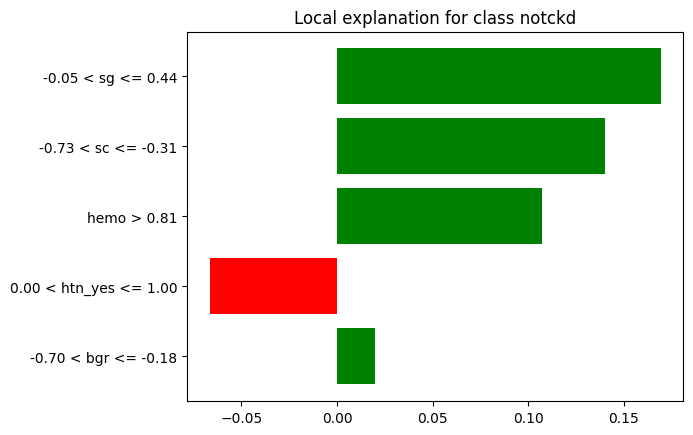

In [ ]:
fig = exp.as_pyplot_figure()

In [ ]:
for i in range(3):
    exp = explainer.explain_instance(
        X.iloc[i].values,
        gb_model.predict_proba
    )
    print(f"\nSample {i}")
    print(exp.as_list())


Sample 0
[('-0.05 < sg <= 0.44', 0.1783590364434422), ('-0.73 < sc <= -0.31', 0.135112034190156), ('hemo > 0.81', 0.10992941105523905), ('0.00 < htn_yes <= 1.00', -0.06900614974902337), ('-0.70 < bgr <= -0.18', 0.022737167723988518)]

Sample 1
[('-0.05 < sg <= 0.44', 0.17627047811627541), ('sc <= -0.73', 0.15863846708502782), ('-0.65 < hemo <= -0.03', -0.09102799436520378), ('htn_yes <= 0.00', 0.0642879459617334), ('-0.18 < bgr <= 0.35', -0.005173470781500971)]

Sample 2
[('sg <= -0.50', -0.19040846727649408), ('-0.31 < sc <= 0.63', -0.14003640309463042), ('hemo <= -0.65', -0.08800464651656964), ('htn_yes <= 0.00', 0.06468624844290126), ('bgr > 0.35', -0.032963567218899766)]


## Decision Path Explanation

In [ ]:
i = 0
sample_df = X.iloc[[i]]

In [ ]:
feature_counts = {col: 0 for col in X.columns}

In [ ]:
for stage in gb_model.estimators_:
    tree = stage[0]
    
    node_indicator = tree.decision_path(sample_df)
    leaf_id = tree.apply(sample_df)
    
    feature = tree.tree_.feature
    threshold = tree.tree_.threshold
    
    node_index = node_indicator.indices
    
    for node_id in node_index:
        if leaf_id[0] == node_id:
            continue
        
        feat_idx = feature[node_id]
        if feat_idx != -2:
            feat_name = X.columns[feat_idx]
            feature_counts[feat_name] += 1

In [ ]:
sorted_features = sorted(feature_counts.items(), key=lambda x: x[1], reverse=True)

In [ ]:
print(f"Decision Path Feature Usage for Sample {i}:\n")
for feat, count in sorted_features:
    if count > 0:
        print(f"{feat}: used {count} times")

Decision Path Feature Usage for Sample 0:

sg: used 3 times
sc: used 3 times
hemo: used 2 times
bgr: used 1 times
htn_yes: used 1 times


## Actual Conditions of one tree

In [ ]:
tree = gb_model.estimators_[0][0]

node_indicator = tree.decision_path(sample_df)
feature = tree.tree_.feature
threshold = tree.tree_.threshold

print("\nDecision path (Tree 0):")

for node_id in node_indicator.indices:
    if feature[node_id] != -2:
        feat_name = X.columns[feature[node_id]]
        thresh = threshold[node_id]
        val = sample_df.iloc[0, feature[node_id]]
        
        if val <= thresh:
            decision = "<="
        else:
            decision = ">"
        
        print(f"{feat_name} ({val:.3f}) {decision} {thresh:.3f}")


Decision path (Tree 0):
sg (0.439) > 0.193


# Anora

## SHAP Interaction values

In [ ]:
explainer = shap.TreeExplainer(model)

In [ ]:
shap_values = explainer.shap_values(X)
print(shap_values)

[[ 0.37317246  0.77610712  0.494205    0.137019   -0.32432802]
 [-0.57415142  0.77610712  0.32972852 -0.21531557  0.22790617]
 [-0.32664393 -0.58888001 -0.60329746 -0.07431299  0.11186475]
 ...
 [ 0.37317246  0.77610712  0.56829902  0.137019    0.22790617]
 [ 0.37317246  0.77610712  0.56829902  0.137019    0.22790617]
 [ 0.37317246  0.77610712  0.56829902  0.137019    0.22790617]]


SHAP beeswarm plot

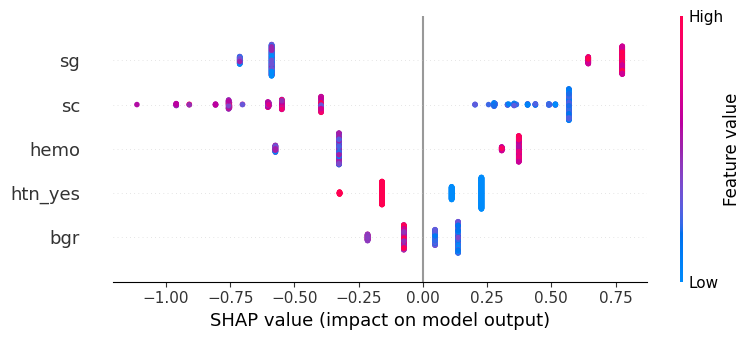

In [ ]:
shap.summary_plot(shap_values, X)

In [ ]:
interaction_values = explainer.shap_interaction_values(X)

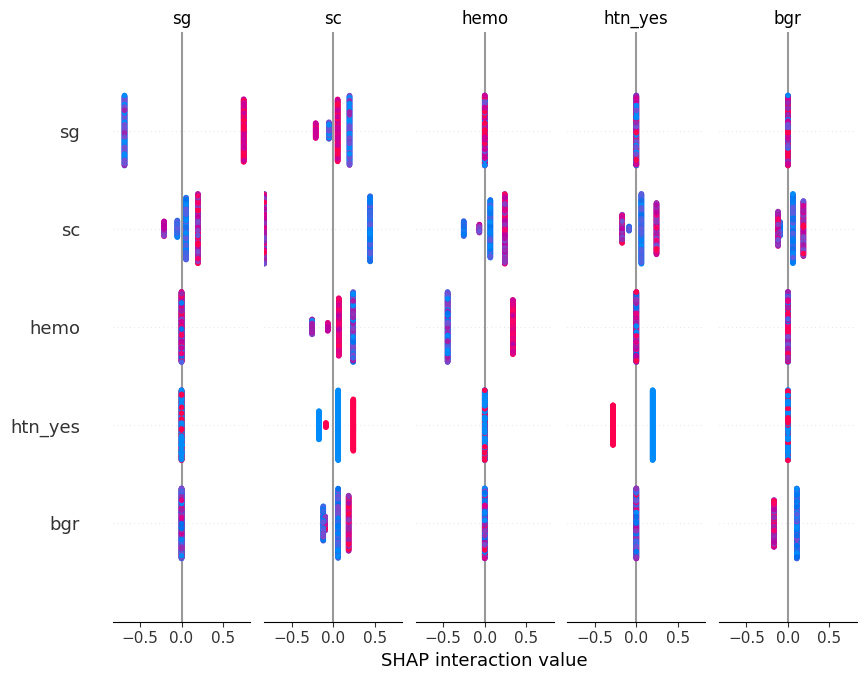

In [ ]:
shap.summary_plot(interaction_values, X)

## ICE

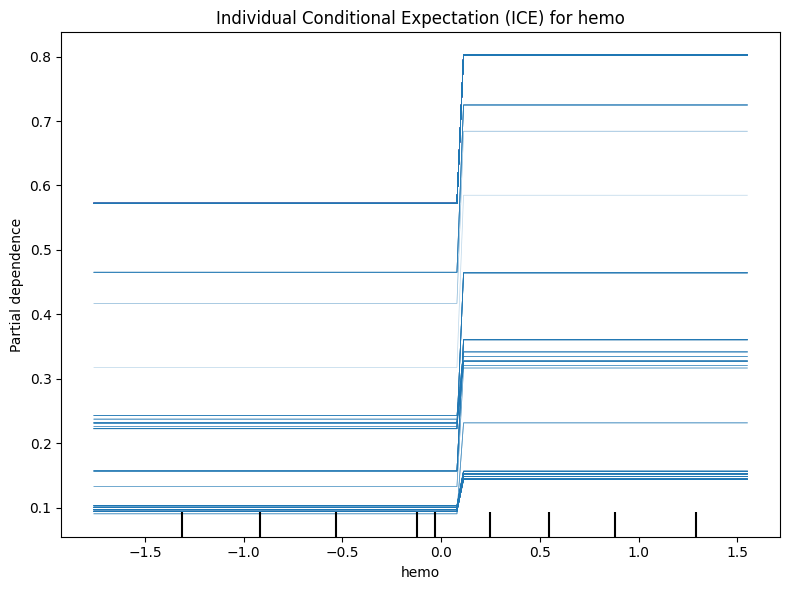

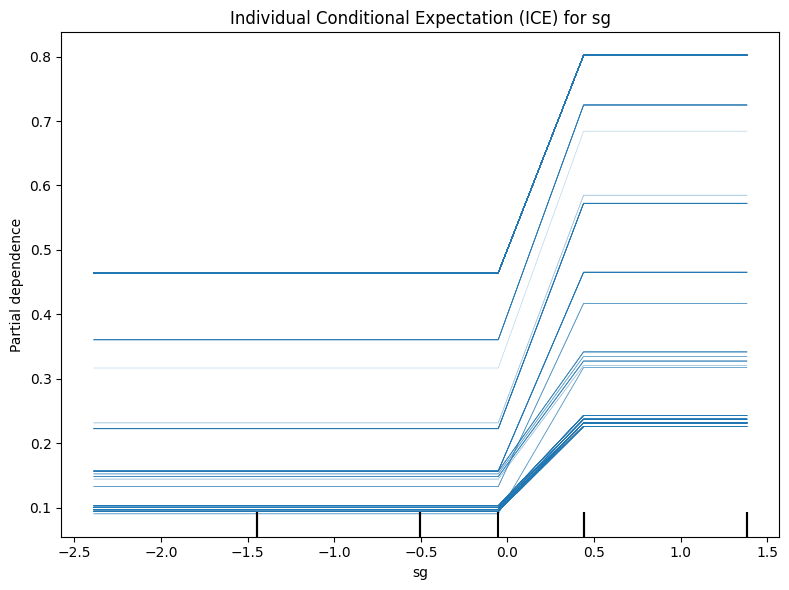

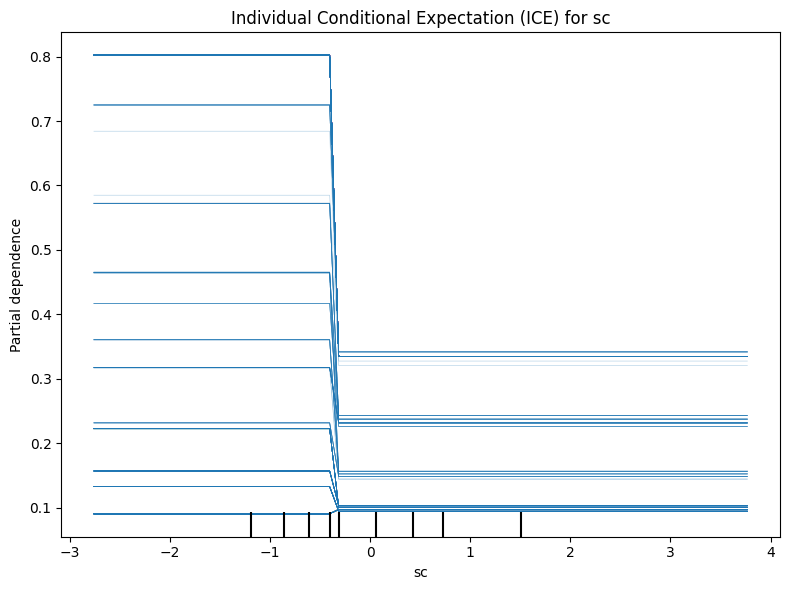

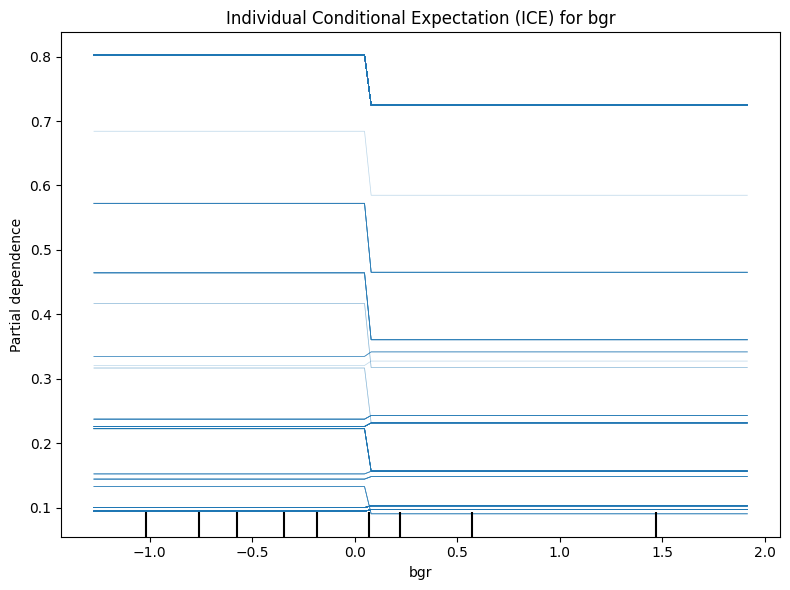

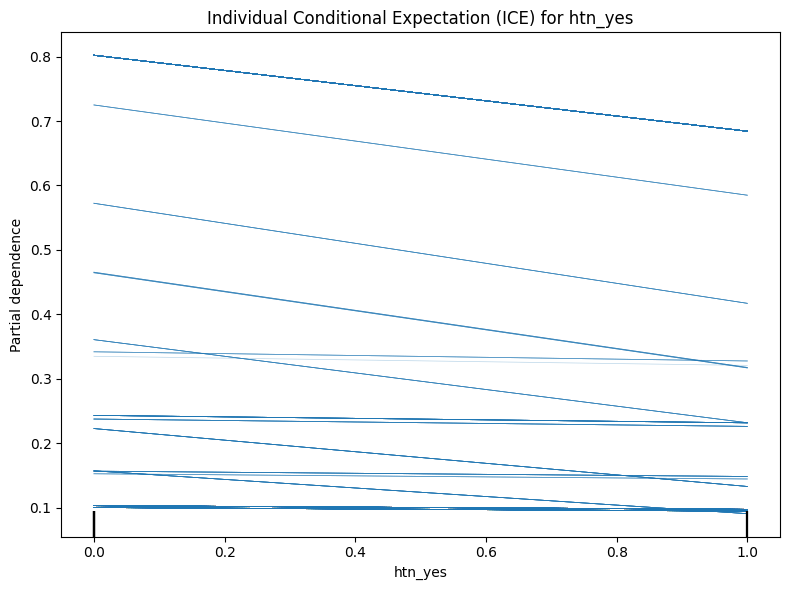

In [ ]:
for feature in X.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    PartialDependenceDisplay.from_estimator(
        model,
        X,
        features=[feature],
        kind="individual",  
        ax=ax
    )
    
    ax.set_title(f"Individual Conditional Expectation (ICE) for {feature}")
    plt.tight_layout()
    plt.show()

## Permutation Feature Importance

In [ ]:
y_true = le.transform(df['classification'])

In [ ]:
result = permutation_importance(
    model,
    X,
    y=y_true,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

In [ ]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

importance_df

,feature,importance_mean,importance_std
1,sg,0.195707,0.013517
2,sc,0.175505,0.012176
0,hemo,0.011616,0.002020
3,bgr,0.007576,0.003746
4,htn_yes,0.003788,0.003788


# Anshu

## Feature Importance

purpose: overall important features

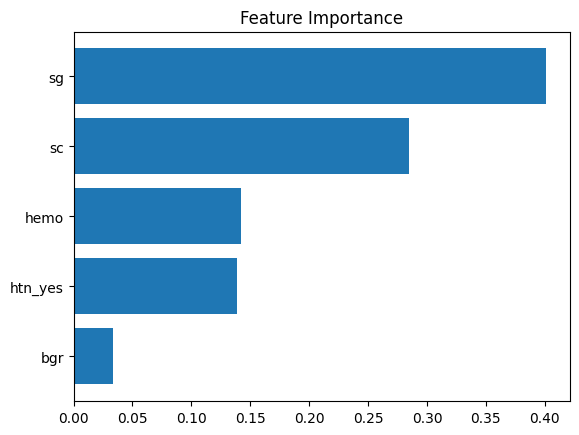

In [ ]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

 Observations

- Specific Gravity (sg) is the most important feature influencing CKD prediction.
- Serum Creatinine (sc) also has a strong impact, indicating kidney function relevance.
- Hemoglobin (hemo) and Hypertension (htn_yes) contribute moderately.
- Blood Glucose Random (bgr) has the least importance among the top features.
- Overall, the model relies more on kidney-related clinical indicators rather than general health metrics.

## PDP

purpose: feature effect on output

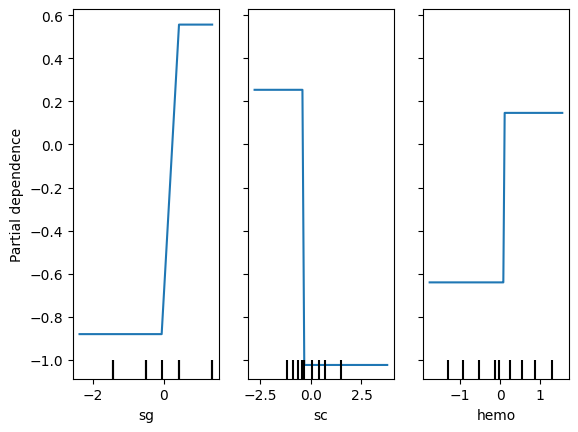

In [ ]:
top_features = importance_df["Feature"].head(3).tolist()

PartialDependenceDisplay.from_estimator(
    model,
    X,
    top_features
)

plt.show()

Observations

- For Specific Gravity (sg), the prediction shows a sharp increase from negative to positive values, indicating that higher sg values significantly increase the likelihood of CKD prediction.

- For Serum Creatinine (sc), the model shows a strong negative trend, meaning higher creatinine values push the prediction strongly toward CKD, reflecting its clinical importance.

- For Hemoglobin (hemo), the relationship is moderately positive, suggesting that changes in hemoglobin levels influence CKD prediction but not as strongly as sg or sc.

- Overall, PDP plots confirm that kidney-specific clinical features (sg and sc) have a dominant effect on model predictions.

PDP shows how each feature independently affects prediction — sg and sc have strong influence, confirming feature importance results.

Graph looks step-like because:

Tree models (Gradient Boost) create piecewise constant predictions

but might not be reliable always coz it assumes feature independence which might not be true always

## TreeSHAP 

purpose: SHAP(local+global explainability) for tree models

c:\Users\v\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


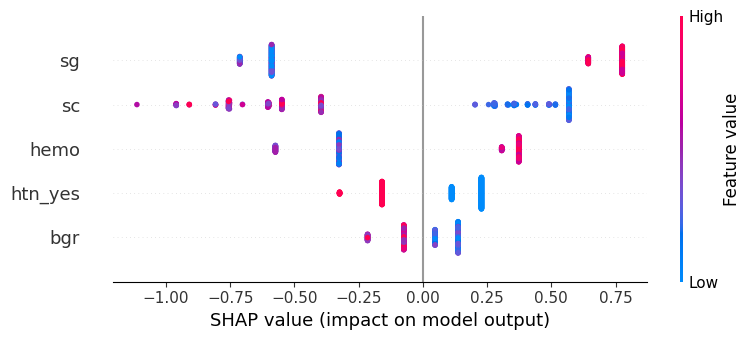

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

c:\Users\v\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


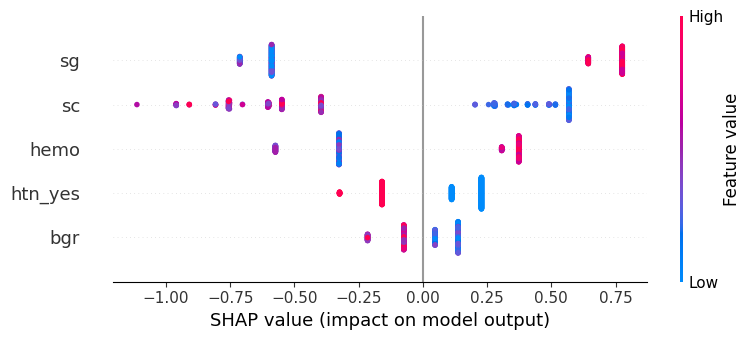

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)


- Right side → pushes toward CKD
- Left side → pushes toward NOT CKD
- Color:
    - Red: High value
    - Blue: Low value

Observations

- Specific Gravity (sg) has the highest impact on predictions. Higher values (red) push the prediction towards CKD, while lower values (blue) push it away.

- Serum Creatinine (sc) shows strong influence, where higher values significantly increase the likelihood of CKD prediction.

- Hemoglobin (hemo) has a moderate effect, where lower values tend to push predictions toward CKD.

- Hypertension (htn_yes) contributes positively to CKD prediction when present.

- Blood Glucose Random (bgr) has relatively lower impact compared to other features.

- Overall, SHAP confirms that kidney-related clinical parameters dominate the model’s decision-making process.

SHAP shows which features push the output toward or away from CKD, both globally and locally.

### Individual Explanation (Local Behavior)

Force plot shows how individual features push a single prediction from base value to final o/p.

In [ ]:
shap.initjs()
shap.force_plot(
    explainer.expected_value, #explaining one prediction using SHAP
    shap_values[0],
    X.iloc[0]
)

Observation:
- Shows contribution of each feature
- Right = increases CKD risk(class 1)
- Left = decreases risk(Class 0)

(force plot labels are feature values (x.iloc[0]values),not SHAP (feature impact) values)

In [ ]:
print("Base value:", explainer.expected_value) #-ve coz SHAP is using log-odds (logit), not probability
#dataset has more non ckd cases,so model's avg predn leans towards non ckd, hence -ve log odds
# this means before seeing any features, model prediction starts at -0.683(this is the mean model o/p over dataset)
#-0.683 in log-odds after sigmoid conversion would be 33%prob of ckd, i.e model leans towards non ckd

Base value: [-0.68316453]


In [ ]:
print(shap_values[0]) #here each no. shows contri of a feature(+ve pushes towards ckd,-ve pushes away)

[ 0.37317246  0.77610712  0.494205    0.137019   -0.32432802]


In [ ]:
import numpy as np

log_odds = 0.77 #base value+all SHAP values basically, -0.683+0.373+0.776+0.494+0.137-0.324=0.773
prob = 1 / (1 + np.exp(-log_odds))

print("Probability:", prob) #so model predicts 68% prob of ckd

Probability: 0.6835208937363156


For this patient:


- The base value (-0.683) represents the average model prediction, before considering feature effects.
- Features like Specific Gravity (sg), Serum Creatinine (sc), Hemoglobin (hemo), and Blood Glucose Random (bgr) incraese ckd likelihood(shown in red).
- Although hypertension (htn_yes = 1) is generally associated with CKD, in this specific instance it slightly pushes the prediction toward the non-CKD side, indicating that its impact is dependent on interactions with other features.
- The combined effect of all features shifts the prediction to 0.77. (this is log-odds value (what model internally uses), we apply sigmoid on this to get final prob(what humans understand)) 
- Final predicted probability is ~0.68, indicating moderate risk of CKD.

## Conclusion

All three methods (Feature Importance, PDP, and SHAP) provide both global and local interpretability and consistently show that Specific Gravity and Serum Creatinine are the most critical features influencing Chronic Kidney Disease prediction.